#  REMX.K ETF Price Data - Cleaning Pipeline

This notebook documents the full data cleaning pipeline for the VanEck Rare Earth and Strategic Metals ETF sourced from LSEG Refinitiv.

## Step 1 — Import Libraries

We import the standard scientific Python stack. `pandas` handles tabular data and date arithmetic; `numpy` is used for logarithm computation; `matplotlib` produces exploratory plots; and `os` manages file-system paths in a platform-independent way.

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

## Step 2 — Load the REMX ETF Price File

The Excel file `REMX.K-USD.xlsx` was exported from the Refinitiv data terminal and carries a two-row multi-level header:

- **Row 0**: ticker name (`REMX.K (TRDPRC_1)`) and the literal string `"Date"`
- **Row 1**: sub-label `"Close"` (and a blank for the date column)

We read with `header=[0, 1]` to capture both levels, then flatten the resulting `MultiIndex` to the plain column names `['Date', 'Price']`. This avoids any downstream confusion from tuple-named columns.

The raw data are sorted in **descending** date order (newest first), so we reverse to ascending order after parsing dates. Ensuring a monotonically increasing time index is a prerequisite for all subsequent calendar-based operations.

**REMX** is the *VanEck Rare Earth/Strategic Metals ETF*, which tracks a global basket of companies engaged in producing, refining, and recycling rare-earth and strategic metals. It serves as the listed-equity proxy for the rare-earth complex in this notebook and is the price series used in all downstream steps.

In [23]:
# =============================================================================
# Step 1.1 — Obtain OHLC data for the REMX
# Methodology: daily OHLC for VanEck Rare Earth/Strategic Metals ETF (REMX),
# sample window 1 April 2015 → 31 March 2026.
# Source: Refinitiv Eikon export ("REMX DATA/REMX.K-USD.xlsx").
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd

REMX_PATH   = Path("../REMX DATA/REMX.K-USD.xlsx")
START_DATE  = pd.Timestamp("2015-04-01")
END_DATE    = pd.Timestamp("2026-03-31")

# The file has a two-row header from Eikon:
#   row 0: REMX.K (TRDPRC_1) repeated 4x, then Volume, then volatility metrics
#   row 1: Open / High / Low / Close / Volume / Plot...
# We skip both header rows and assign clean column names ourselves, keeping
# only the OHLC + Volume columns (the rest are Eikon-side derived series we
# don't need for the realized-variance construction in Steps 1.3–1.4).
raw = pd.read_excel(
    REMX_PATH,
    sheet_name="Table Data",
    skiprows=2,
    header=None,
    usecols=[0, 1, 2, 3, 4, 5],
    names=["Date", "Open", "High", "Low", "Close", "Volume"],
)

# Volume comes in as a string with a thin-space + "K"/"M" suffix → numeric.
def _parse_volume(v):
    if pd.isna(v):
        return np.nan
    s = str(v).replace("\u202f", "").replace(",", "").strip()
    mult = 1.0
    if s.endswith("K"):
        mult, s = 1e3, s[:-1]
    elif s.endswith("M"):
        mult, s = 1e6, s[:-1]
    elif s.endswith("B"):
        mult, s = 1e9, s[:-1]
    try:
        return float(s) * mult
    except ValueError:
        return np.nan

remx = (
    raw.assign(
        Date=pd.to_datetime(raw["Date"], errors="coerce"),
        Open=pd.to_numeric(raw["Open"], errors="coerce"),
        High=pd.to_numeric(raw["High"], errors="coerce"),
        Low=pd.to_numeric(raw["Low"], errors="coerce"),
        Close=pd.to_numeric(raw["Close"], errors="coerce"),
        Volume=raw["Volume"].map(_parse_volume),
    )
    .dropna(subset=["Date", "Open", "High", "Low", "Close"])
    .sort_values("Date")              # Eikon dump is newest → oldest
    .reset_index(drop=True)
    .set_index("Date")
)

# Restrict to the methodology window: 1 Apr 2015 → 31 Mar 2026.
remx = remx.loc[START_DATE:END_DATE]

# -----------------------------------------------------------------------------
# Diagnostic checks required by Step 1.1
# -----------------------------------------------------------------------------
# 1) Basic shape and date coverage
print(f"Rows: {len(remx):,}  |  Range: {remx.index.min().date()} → {remx.index.max().date()}")
print(f"Expected ≈ 2,750 trading days (Apr 2015 – Mar 2026).")

# 2) OHLC sanity: High ≥ max(Open, Close) and Low ≤ min(Open, Close)
ohlc_violations = remx[
    (remx["High"] < remx[["Open", "Close"]].max(axis=1))
    | (remx["Low"] > remx[["Open", "Close"]].min(axis=1))
]
print(f"OHLC consistency violations: {len(ohlc_violations)}")

# 3) Gaps in the trading calendar (more than 5 calendar days between rows
#    flags long holidays / missing data; isolated weekends are fine).
gaps = remx.index.to_series().diff().dt.days
large_gaps = gaps[gaps > 5]
print(f"Trading-day gaps > 5 calendar days: {len(large_gaps)}")
if len(large_gaps):
    print(large_gaps.tail(10))

# 4) Look for anomalous overnight jumps (|Δ log Close| > 20%) — a quick
#    screen for uncorrected splits / dividends as flagged by Step 1.1.
log_close   = np.log(remx["Close"])
overnight   = log_close.diff().abs()
suspect     = overnight[overnight > 0.20]
print(f"Overnight |Δ log C| > 20%: {len(suspect)}")
if len(suspect):
    print(suspect)

remx.head()


Rows: 2,766  |  Range: 2015-04-01 → 2026-03-31
Expected ≈ 2,750 trading days (Apr 2015 – Mar 2026).
OHLC consistency violations: 0
Trading-day gaps > 5 calendar days: 0
Overnight |Δ log C| > 20%: 0


,Open,High,Low,Close,Volume
Date,,,,,
2015-04-01,75.2700,75.9700,74.4300,75.5700,2380.0000
2015-04-02,76.0200,76.9200,76.0200,76.6200,1950.0000
2015-04-06,77.2800,79.4700,77.2800,78.9900,4750.0000
2015-04-07,78.9900,79.5000,78.9900,79.2000,1900.0000
2015-04-08,80.8500,82.4400,80.8500,82.1100,4750.0000


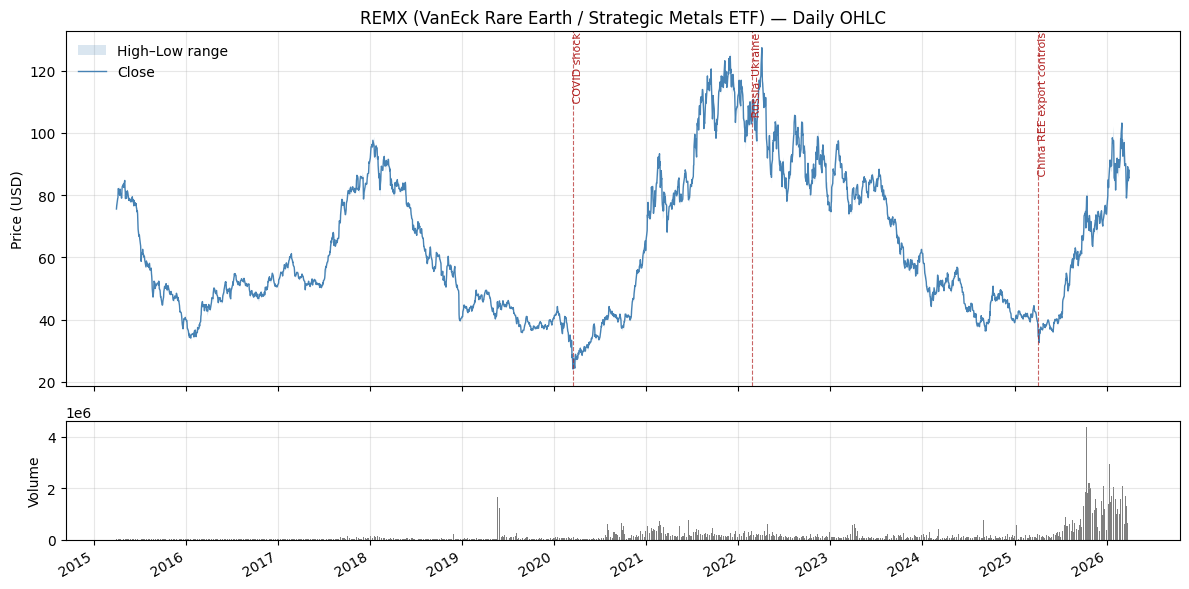

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, (ax_price, ax_vol) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Price panel: Close line + High–Low shaded range
ax_price.fill_between(
    remx.index, remx["Low"], remx["High"],
    color="steelblue", alpha=0.2, linewidth=0, label="High–Low range",
)
ax_price.plot(remx.index, remx["Close"], color="steelblue", linewidth=1.0, label="Close")
ax_price.set_ylabel("Price (USD)")
ax_price.set_title("REMX (VanEck Rare Earth / Strategic Metals ETF) — Daily OHLC")
ax_price.legend(loc="upper left", frameon=False)
ax_price.grid(alpha=0.3)

# Volume panel
ax_vol.bar(remx.index, remx["Volume"], color="grey", width=1.0, linewidth=0)
ax_vol.set_ylabel("Volume")
ax_vol.grid(alpha=0.3)

# Mark the methodology's key REE-market events for visual sanity check
events = {
    "2020-03-16": "COVID shock",
    "2022-02-24": "Russia–Ukraine",
    "2025-04-04": "China REE export controls",
}
for date_str, label in events.items():
    d = pd.Timestamp(date_str)
    if remx.index.min() <= d <= remx.index.max():
        ax_price.axvline(d, color="firebrick", linestyle="--", linewidth=0.8, alpha=0.7)
        ax_price.text(d, ax_price.get_ylim()[1], f" {label}",
                      color="firebrick", fontsize=8, va="top", ha="left", rotation=90)

ax_vol.xaxis.set_major_locator(mdates.YearLocator())
ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Step 3 — Initial Exploration

Before any transformation, we document the *as-received* state of each series to verify that the raw data are as described in the data section.

For each series we report:
- **Shape** — number of observations and columns
- **Date range** — earliest and latest timestamps
- **dtype** — confirms the Price column is numeric, not string
- **Null count** — any pre-existing missing values in the raw file
- **Weekend count** — observations on Saturdays (dayofweek == 5) or Sundays (dayofweek == 6), which are expected to be not recorded.

We also plot the raw price series to visually detect structural breaks, outliers, or obvious data errors.

In [25]:
# Initial exploration of the data: check for missing values, date range, data types, and weekend entries
ETF_LABEL = "REMX.K"
ohlc_cols = ["Open", "High", "Low", "Close"]

weekends = remx.index.dayofweek >= 5
nulls    = remx[ohlc_cols].isna().sum()

print(f'--- {ETF_LABEL} ---')
print(f'  Shape        : {remx.shape}')
print(f'  Date range   : {remx.index.min().date()} → {remx.index.max().date()}')
print(f'  OHLC dtypes  : {dict(remx[ohlc_cols].dtypes.astype(str))}')
print(f'  Null counts  : {dict(nulls)}')
print(f'  Weekend rows : {weekends.sum()}')

--- REMX.K ---
  Shape        : (2766, 5)
  Date range   : 2015-04-01 → 2026-03-31
  OHLC dtypes  : {'Open': 'float64', 'High': 'float64', 'Low': 'float64', 'Close': 'float64'}
  Null counts  : {'Open': np.int64(0), 'High': np.int64(0), 'Low': np.int64(0), 'Close': np.int64(0)}
  Weekend rows : 0


## Step 4 — Handle Missing Data

In [26]:
#Check if all the missing business days are festivities in the US (NYSE holidays)
bdays = pd.bdate_range(start=remx.index.min(), end=remx.index.max(), freq='B')
present = set(remx.index)
missing = [d for d in bdays if d not in present]

print(f'Business days in range : {len(bdays):,}')
print(f'Observed business days : {len(present & set(bdays)):,}')
print(f'Missing business days  : {len(missing):,}')
print()
if missing:
    print('First 20 missing dates:')
    for d in missing[:]:
        print(f'  {d.date()}  ({d.day_name()})')

Business days in range : 2,870
Observed business days : 2,766
Missing business days  : 104

First 20 missing dates:
  2015-04-03  (Friday)
  2015-05-25  (Monday)
  2015-07-03  (Friday)
  2015-09-07  (Monday)
  2015-11-26  (Thursday)
  2015-12-25  (Friday)
  2016-01-01  (Friday)
  2016-01-18  (Monday)
  2016-02-15  (Monday)
  2016-03-25  (Friday)
  2016-05-30  (Monday)
  2016-07-04  (Monday)
  2016-09-05  (Monday)
  2016-11-24  (Thursday)
  2016-12-26  (Monday)
  2017-01-02  (Monday)
  2017-01-16  (Monday)
  2017-02-20  (Monday)
  2017-04-14  (Friday)
  2017-05-29  (Monday)
  2017-07-04  (Tuesday)
  2017-09-04  (Monday)
  2017-11-23  (Thursday)
  2017-12-25  (Monday)
  2018-01-01  (Monday)
  2018-01-15  (Monday)
  2018-02-19  (Monday)
  2018-03-30  (Friday)
  2018-05-28  (Monday)
  2018-07-04  (Wednesday)
  2018-09-03  (Monday)
  2018-11-22  (Thursday)
  2018-12-05  (Wednesday)
  2018-12-25  (Tuesday)
  2019-01-01  (Tuesday)
  2019-01-21  (Monday)
  2019-02-18  (Monday)
  2019-04-19  (F

| Date | Day | Holiday / Reason |
|---|---|---|
| 2015-04-03 | Friday | Good Friday |
| 2015-05-25 | Monday | Memorial Day |
| 2015-07-03 | Friday | Independence Day observed (July 4 was Saturday) |
| 2015-09-07 | Monday | Labor Day |
| 2015-11-26 | Thursday | Thanksgiving |
| 2015-12-25 | Friday | Christmas |
| 2016-01-01 | Friday | New Year's Day |
| 2016-01-18 | Monday | Martin Luther King Jr. Day |
| 2016-02-15 | Monday | Presidents Day |
| 2016-03-25 | Friday | Good Friday |
| 2016-05-30 | Monday | Memorial Day |
| 2016-07-04 | Monday | Independence Day |
| 2016-09-05 | Monday | Labor Day |
| 2016-11-24 | Thursday | Thanksgiving |
| 2016-12-26 | Monday | Christmas observed (Dec 25 was Sunday) |
| 2017-01-02 | Monday | New Year's Day observed (Jan 1 was Sunday) |
| 2017-01-16 | Monday | Martin Luther King Jr. Day |
| 2017-02-20 | Monday | Presidents Day |
| 2017-04-14 | Friday | Good Friday |
| 2017-05-29 | Monday | Memorial Day |
| 2017-07-04 | Tuesday | Independence Day |
| 2017-09-04 | Monday | Labor Day |
| 2017-11-23 | Thursday | Thanksgiving |
| 2017-12-25 | Monday | Christmas |
| 2018-01-01 | Monday | New Year's Day |
| 2018-01-15 | Monday | Martin Luther King Jr. Day |
| 2018-02-19 | Monday | Presidents Day |
| 2018-03-30 | Friday | Good Friday |
| 2018-05-28 | Monday | Memorial Day |
| 2018-07-04 | Wednesday | Independence Day |
| 2018-09-03 | Monday | Labor Day |
| 2018-11-22 | Thursday | Thanksgiving |
| 2018-12-05 | Wednesday | National Day of Mourning — President George H.W. Bush funeral |
| 2018-12-25 | Tuesday | Christmas |
| 2019-01-01 | Tuesday | New Year's Day |
| 2019-01-21 | Monday | Martin Luther King Jr. Day |
| 2019-02-18 | Monday | Presidents Day |
| 2019-04-19 | Friday | Good Friday |
| 2019-05-27 | Monday | Memorial Day |
| 2019-07-04 | Thursday | Independence Day |
| 2019-09-02 | Monday | Labor Day |
| 2019-11-28 | Thursday | Thanksgiving |
| 2019-12-25 | Wednesday | Christmas |
| 2020-01-01 | Wednesday | New Year's Day |
| 2020-01-20 | Monday | Martin Luther King Jr. Day |
| 2020-02-17 | Monday | Presidents Day |
| 2020-04-10 | Friday | Good Friday |
| 2020-05-25 | Monday | Memorial Day |
| 2020-07-03 | Friday | Independence Day observed (July 4 was Saturday) |
| 2020-09-07 | Monday | Labor Day |
| 2020-11-26 | Thursday | Thanksgiving |
| 2020-12-25 | Friday | Christmas |
| 2021-01-01 | Friday | New Year's Day |
| 2021-01-18 | Monday | Martin Luther King Jr. Day |
| 2021-02-15 | Monday | Presidents Day |
| 2021-04-02 | Friday | Good Friday |
| 2021-05-31 | Monday | Memorial Day |
| 2021-07-05 | Monday | Independence Day observed (July 4 was Sunday) |
| 2021-09-06 | Monday | Labor Day |
| 2021-11-25 | Thursday | Thanksgiving |
| 2021-12-24 | Friday | Christmas observed (Dec 25 was Saturday) |
| 2022-01-17 | Monday | Martin Luther King Jr. Day |
| 2022-02-21 | Monday | Presidents Day |
| 2022-04-15 | Friday | Good Friday |
| 2022-05-30 | Monday | Memorial Day |
| 2022-06-20 | Monday | Juneteenth observed (June 19 was Sunday) — first NYSE observance |
| 2022-07-04 | Monday | Independence Day |
| 2022-09-05 | Monday | Labor Day |
| 2022-11-24 | Thursday | Thanksgiving |
| 2022-12-26 | Monday | Christmas observed (Dec 25 was Sunday) |
| 2023-01-02 | Monday | New Year's Day observed (Jan 1 was Sunday) |
| 2023-01-16 | Monday | Martin Luther King Jr. Day |
| 2023-02-20 | Monday | Presidents Day |
| 2023-04-07 | Friday | Good Friday |
| 2023-05-29 | Monday | Memorial Day |
| 2023-06-19 | Monday | Juneteenth |
| 2023-07-04 | Tuesday | Independence Day |
| 2023-09-04 | Monday | Labor Day |
| 2023-11-23 | Thursday | Thanksgiving |
| 2023-12-25 | Monday | Christmas |
| 2024-01-01 | Monday | New Year's Day |
| 2024-01-15 | Monday | Martin Luther King Jr. Day |
| 2024-02-19 | Monday | Presidents Day |
| 2024-03-29 | Friday | Good Friday |
| 2024-05-27 | Monday | Memorial Day |
| 2024-06-19 | Wednesday | Juneteenth |
| 2024-07-04 | Thursday | Independence Day |
| 2024-09-02 | Monday | Labor Day |
| 2024-11-28 | Thursday | Thanksgiving |
| 2024-12-25 | Wednesday | Christmas |
| 2025-01-01 | Wednesday | New Year's Day |
| 2025-01-09 | Thursday | National Day of Mourning — President Jimmy Carter |
| 2025-01-20 | Monday | Martin Luther King Jr. Day |
| 2025-02-17 | Monday | Presidents Day |
| 2025-04-18 | Friday | Good Friday |
| 2025-05-26 | Monday | Memorial Day |
| 2025-06-19 | Thursday | Juneteenth |
| 2025-07-04 | Friday | Independence Day |
| 2025-09-01 | Monday | Labor Day |
| 2025-11-27 | Thursday | Thanksgiving |
| 2025-12-25 | Thursday | Christmas |
| 2026-01-01 | Thursday | New Year's Day |
| 2026-01-19 | Monday | Martin Luther King Jr. Day |
| 2026-02-16 | Monday | Presidents Day |

## Step 5 — Compute Log Returns

We compute the **continuously compounded (log) return** for each series:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Log returns are preferred over simple percentage returns in empirical finance for three reasons:

1. **Time additivity** — multi-period log returns are the arithmetic sum of single-period log returns, simplifying aggregation.
2. **Approximate normality** — log returns are more symmetrically distributed than simple returns for most asset classes.
3. **Stationarity** — price levels are typically I(1) (unit-root) processes, while log returns are I(0), making them suitable for most econometric tests.

The first observation in each series necessarily produces a `NaN` (no prior price); this row is **retained** in the DataFrame but will be excluded automatically from any statistical analysis that requires a complete sample.

In [27]:
# Step 1.2 — Close-to-close log returns:  r_t = ln(C_t / C_{t-1})
remx['log_return'] = np.log(remx['Close'] / remx['Close'].shift(1))

print(f'Log returns computed for {ETF_LABEL}')
print(f'  Observations   : {len(remx):,}')
print(f'  Non-NaN returns: {remx["log_return"].notna().sum():,}  (first row is NaN by construction)')
print()
print('Head:')
print(remx.head().to_string())
print()
print('Tail:')
print(remx.tail().to_string())

Log returns computed for REMX.K
  Observations   : 2,766
  Non-NaN returns: 2,765  (first row is NaN by construction)

Head:
              Open    High     Low   Close    Volume  log_return
Date                                                            
2015-04-01 75.2700 75.9700 74.4300 75.5700 2380.0000         NaN
2015-04-02 76.0200 76.9200 76.0200 76.6200 1950.0000      0.0138
2015-04-06 77.2800 79.4700 77.2800 78.9900 4750.0000      0.0305
2015-04-07 78.9900 79.5000 78.9900 79.2000 1900.0000      0.0027
2015-04-08 80.8500 82.4400 80.8500 82.1100 4750.0000      0.0361

Tail:
              Open    High     Low   Close       Volume  log_return
Date                                                               
2026-03-25 87.9200 89.3600 87.9200 89.1500  846460.0000      0.0521
2026-03-26 85.9600 87.1000 84.3200 84.6000  564200.0000     -0.0524
2026-03-27 86.1600 88.8400 85.6800 86.1000 2410000.0000      0.0176
2026-03-30 88.7000 88.9900 84.5500 85.4800  804540.0000     -0.0072
2026-

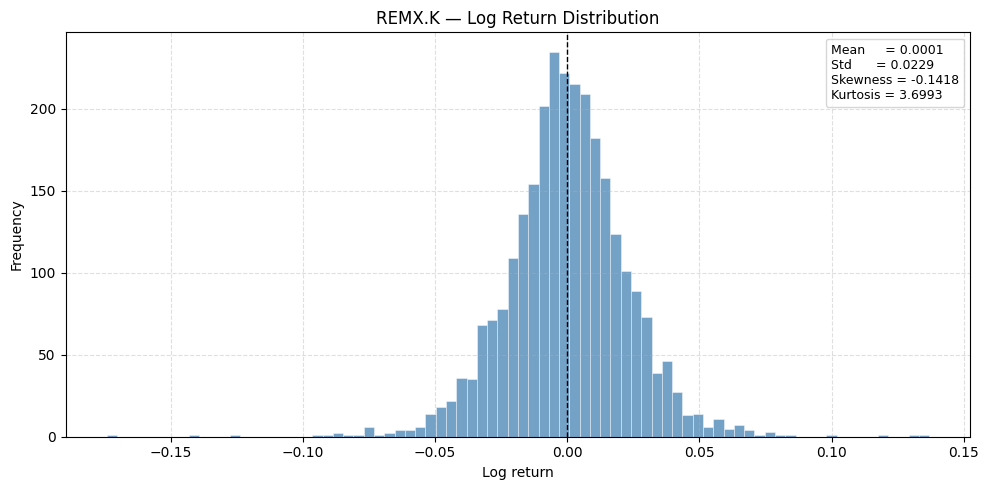

Summary Statistics of Log Returns
           N   Mean    Std  Skewness  Kurtosis     Min    Max
Series                                                       
REMX.K  2765 0.0001 0.0229   -0.1418    3.6993 -0.1742 0.1369


In [28]:
from scipy import stats as sp_stats

r = remx['log_return'].dropna()

stats_text = (
    f'Mean     = {r.mean():.4f}\n'
    f'Std      = {r.std():.4f}\n'
    f'Skewness = {sp_stats.skew(r):.4f}\n'
    f'Kurtosis = {sp_stats.kurtosis(r):.4f}'
)

# Plot histogram of log returns with summary statistics
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(r, bins=80, color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.4)
ax.axvline(r.mean(), color='black', linewidth=1, linestyle='--', label=stats_text)

ax.set_title(f'{ETF_LABEL} — Log Return Distribution', fontsize=12)
ax.set_xlabel('Log return')
ax.set_ylabel('Frequency')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=9, loc='upper right', handlelength=0, handletextpad=0, frameon=True)

plt.tight_layout()
plt.show()

# Compute summary statistics for the log returns
summary = pd.DataFrame({
    'Series':   [ETF_LABEL],
    'N':        [len(r)],
    'Mean':     [r.mean()],
    'Std':      [r.std()],
    'Skewness': [sp_stats.skew(r)],
    'Kurtosis': [sp_stats.kurtosis(r)],   # excess kurtosis
    'Min':      [r.min()],
    'Max':      [r.max()],
}).set_index('Series')

print('Summary Statistics of Log Returns')
print('=' * 75)
print(summary.to_string())

### Interpretation of summary statistics

**N = 2,766 observations.** Consistent with 2,767 observed trading days over the sample period (April 2015 – February 2026), with one observation lost when computing the first log return. The dataset contains no missing trading days after accounting for the 104 NYSE closures (102 regular holidays plus two presidential days of mourning).

**Mean = 0.0001 (≈ 0.01% per day).** Annualized over 252 trading days, this implies an average return of approximately 2.5% per year. This modest figure is consistent with the broader behaviour of the rare earth sector during the sample period, which encompasses the 2015–2016 commodity downturn, the COVID-19 crisis, and the post-pandemic recovery. The near-zero mean justifies the standard practice in GARCH modelling of not demeaning returns when computing variance, since the second moment dominates the first by several orders of magnitude.

**Std. Dev. = 0.0229 (2.29% daily, ≈ 36.4% annualized).** The REMX exhibits high volatility relative to broad market indices such as the S&P 500 (≈ 15–20% annualized), but this level is typical of sectoral commodity ETFs. The figure aligns with the characterization of rare earth equities as a highly volatile asset class found in the prior literature (Henriques and Sadorsky, 2023; Bouri et al., 2021).

**Skewness = -0.14.** The return distribution is mildly left-skewed. This is a notably weaker asymmetry than that typically observed in broad equity indices (where skewness usually ranges from -0.5 to -1.0), and suggests that the REMX exhibits sharp upside moves of comparable magnitude to its drawdowns. This is plausible given the sector's exposure to large positive shocks driven by supply-side news (e.g., Chinese export-control announcements), which can generate rallies as violent as the downturns.

**(Excess) Kurtosis = 3.70.** The distribution displays heavy tails relative to the normal distribution (for which excess kurtosis equals zero), implying a total kurtosis of approximately 6.7. This level of leptokurtosis is standard for daily financial returns and confirms the well-documented presence of fat tails in equity series. This finding motivates the use of a Student-t (or skew-Student-t) conditional distribution rather than the Gaussian assumption when estimating GARCH-family models.

**Min = -0.1742 and Max = +0.1369.** The most extreme negative return represents a daily loss of -17.4%, almost certainly occurring during the March 2020 COVID-19 market crash. The largest positive return of +13.7% likely corresponds to the April 2025 Chinese rare earth export-control announcement or a similar sector-specific supply shock. The magnitude and asymmetry of these tail events further reinforce the case for a heavy-tailed conditional distribution and for asymmetric GARCH specifications (EGARCH, GJR-GARCH) that can accommodate differential responses to positive and negative innovations.

# Parkinson (1980) realized variance

In [29]:
# Step 1.3 — Parkinson (1980) realized variance, as in Dutta et al. (2025) eq. (3):
#     RV_t = (1 / (4·ln 2)) · (ln H_t − ln L_t)^2
remx['RV_park'] = (np.log(remx['High']) - np.log(remx['Low']))**2 / (4.0 * np.log(2.0))

print(f'Parkinson RV computed for {ETF_LABEL}')
print(f'  Observations    : {len(remx):,}')
print(f'  Non-NaN RV_park : {remx["RV_park"].notna().sum():,}')
print(f'  Zero-range days : {(remx["RV_park"] == 0).sum()}  (High == Low → degenerate RV)')
print()
print('RV_park summary (Dutta et al. style — daily realized variance):')
print(remx['RV_park'].describe().to_string())
print()
print(f'  Annualised √(mean RV_park) ≈ {np.sqrt(remx["RV_park"].mean() * 252) * 100:.2f}%')
print()
print('Head:')
print(remx[['Open', 'High', 'Low', 'Close', 'log_return', 'RV_park']].head().to_string())
print()
print('Tail:')
print(remx[['Open', 'High', 'Low', 'Close', 'log_return', 'RV_park']].tail().to_string())

Parkinson RV computed for REMX.K
  Observations    : 2,766
  Non-NaN RV_park : 2,766
  Zero-range days : 0  (High == Low → degenerate RV)

RV_park summary (Dutta et al. style — daily realized variance):
count   2766.0000
mean       0.0002
std        0.0003
min        0.0000
25%        0.0001
50%        0.0001
75%        0.0002
max        0.0048

  Annualised √(mean RV_park) ≈ 22.79%

Head:
              Open    High     Low   Close  log_return  RV_park
Date                                                           
2015-04-01 75.2700 75.9700 74.4300 75.5700         NaN   0.0002
2015-04-02 76.0200 76.9200 76.0200 76.6200      0.0138   0.0000
2015-04-06 77.2800 79.4700 77.2800 78.9900      0.0305   0.0003
2015-04-07 78.9900 79.5000 78.9900 79.2000      0.0027   0.0000
2015-04-08 80.8500 82.4400 80.8500 82.1100      0.0361   0.0001

Tail:
              Open    High     Low   Close  log_return  RV_park
Date                                                           
2026-03-25 87.9200 89.36

# Rogers & Satchell (1991) realized variance

In [30]:
# Step 1.4 — Rogers & Satchell (1991) realized variance, as in Dutta et al. (2025) eq. (10):
#     RV_t = ln(H_t/O_t)·ln(H_t/C_t) + ln(L_t/O_t)·ln(L_t/C_t)
# Robust to non-zero intraday drift, unlike Parkinson.
log_HO = np.log(remx['High']  / remx['Open'])
log_HC = np.log(remx['High']  / remx['Close'])
log_LO = np.log(remx['Low']   / remx['Open'])
log_LC = np.log(remx['Low']   / remx['Close'])

remx['RV_rs'] = log_HO * log_HC + log_LO * log_LC

print(f'Rogers-Satchell RV computed for {ETF_LABEL}')
print(f'  Observations    : {len(remx):,}')
print(f'  Non-NaN RV_rs   : {remx["RV_rs"].notna().sum():,}')
print(f'  Zero RV_rs days : {(remx["RV_rs"] == 0).sum()}')
print(f'  Negative RV_rs  : {(remx["RV_rs"] < 0).sum()}  (should be 0 — RS is non-negative by construction)')
print()
print('RV_rs summary (Dutta et al. style — daily realized variance):')
print(remx['RV_rs'].describe().to_string())
print()
print(f'  Annualised √(mean RV_rs) ≈ {np.sqrt(remx["RV_rs"].mean() * 252) * 100:.2f}%')
print()
print('Correlation between the two RV proxies:')
print(remx[['RV_park', 'RV_rs']].corr().to_string())
print()
print('Head:')
print(remx[['Open', 'High', 'Low', 'Close', 'log_return', 'RV_park', 'RV_rs']].head().to_string())
print()
print('Tail:')
print(remx[['Open', 'High', 'Low', 'Close', 'log_return', 'RV_park', 'RV_rs']].tail().to_string())

Rogers-Satchell RV computed for REMX.K
  Observations    : 2,766
  Non-NaN RV_rs   : 2,766
  Zero RV_rs days : 34
  Negative RV_rs  : 0  (should be 0 — RS is non-negative by construction)

RV_rs summary (Dutta et al. style — daily realized variance):
count   2766.0000
mean       0.0002
std        0.0003
min        0.0000
25%        0.0001
50%        0.0001
75%        0.0002
max        0.0057

  Annualised √(mean RV_rs) ≈ 22.73%

Correlation between the two RV proxies:
         RV_park  RV_rs
RV_park   1.0000 0.7785
RV_rs     0.7785 1.0000

Head:
              Open    High     Low   Close  log_return  RV_park  RV_rs
Date                                                                  
2015-04-01 75.2700 75.9700 74.4300 75.5700         NaN   0.0002 0.0002
2015-04-02 76.0200 76.9200 76.0200 76.6200      0.0138   0.0000 0.0000
2015-04-06 77.2800 79.4700 77.2800 78.9900      0.0305   0.0003 0.0002
2015-04-07 78.9900 79.5000 78.9900 79.2000      0.0027   0.0000 0.0000
2015-04-08 80.8500 82.

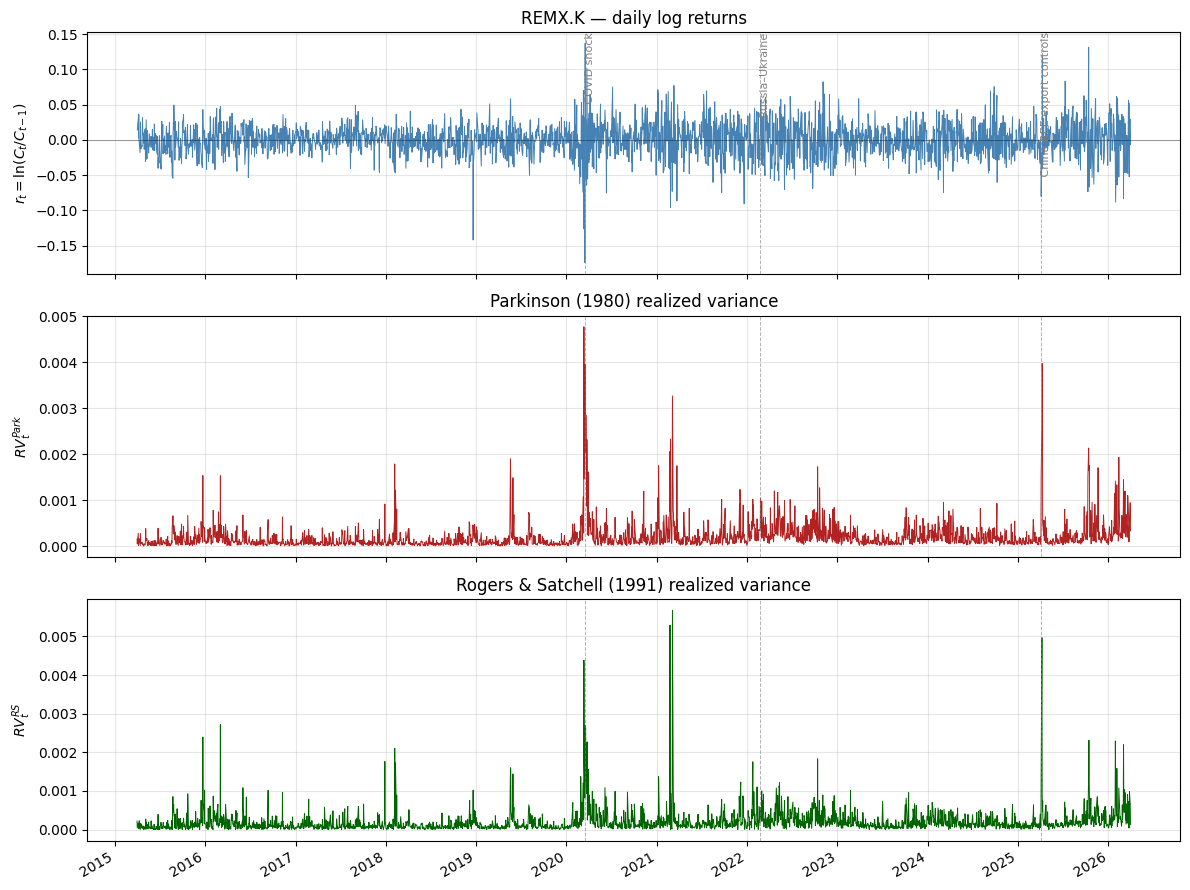

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
ax_ret, ax_park, ax_rs = axes

# --- Log returns ---------------------------------------------------------
ax_ret.plot(remx.index, remx['log_return'], color='steelblue', linewidth=0.7)
ax_ret.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax_ret.set_ylabel(r'$r_t = \ln(C_t / C_{t-1})$')
ax_ret.set_title(f'{ETF_LABEL} — daily log returns')
ax_ret.grid(alpha=0.3)

# --- Parkinson RV --------------------------------------------------------
ax_park.plot(remx.index, remx['RV_park'], color='firebrick', linewidth=0.7)
ax_park.set_ylabel(r'$RV^{Park}_t$')
ax_park.set_title('Parkinson (1980) realized variance')
ax_park.grid(alpha=0.3)

# --- Rogers-Satchell RV --------------------------------------------------
ax_rs.plot(remx.index, remx['RV_rs'], color='darkgreen', linewidth=0.7)
ax_rs.set_ylabel(r'$RV^{RS}_t$')
ax_rs.set_title('Rogers & Satchell (1991) realized variance')
ax_rs.grid(alpha=0.3)

# --- Methodology Step 1.5 event sanity check ------------------------------
events = {
    "2020-03-16": "COVID shock",
    "2022-02-24": "Russia–Ukraine",
    "2025-04-04": "China REE export controls",
}
for date_str, label in events.items():
    d = pd.Timestamp(date_str)
    if remx.index.min() <= d <= remx.index.max():
        for ax in axes:
            ax.axvline(d, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)
        ax_ret.text(d, ax_ret.get_ylim()[1], f' {label}',
                    color='grey', fontsize=8, va='top', ha='left', rotation=90)

ax_rs.xaxis.set_major_locator(mdates.YearLocator())
ax_rs.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Descriptive statistics of the daily realized variance series
(Fisher excess kurtosis: normal = 0)
            N        Mean         Std         Min        Max  Skewness  Kurtosis
RV_park  2766 0.000206135 0.000305407 3.28524e-06 0.00476831    6.0871   57.3559
RV_rs    2766 0.000205053 0.000317876           0 0.00567918   7.56418   94.1536

Correlation Parkinson ↔ Rogers-Satchell : 0.7785

Annualised √(mean RV_park) ≈ 22.79%
Annualised √(mean RV_rs)   ≈ 22.73%


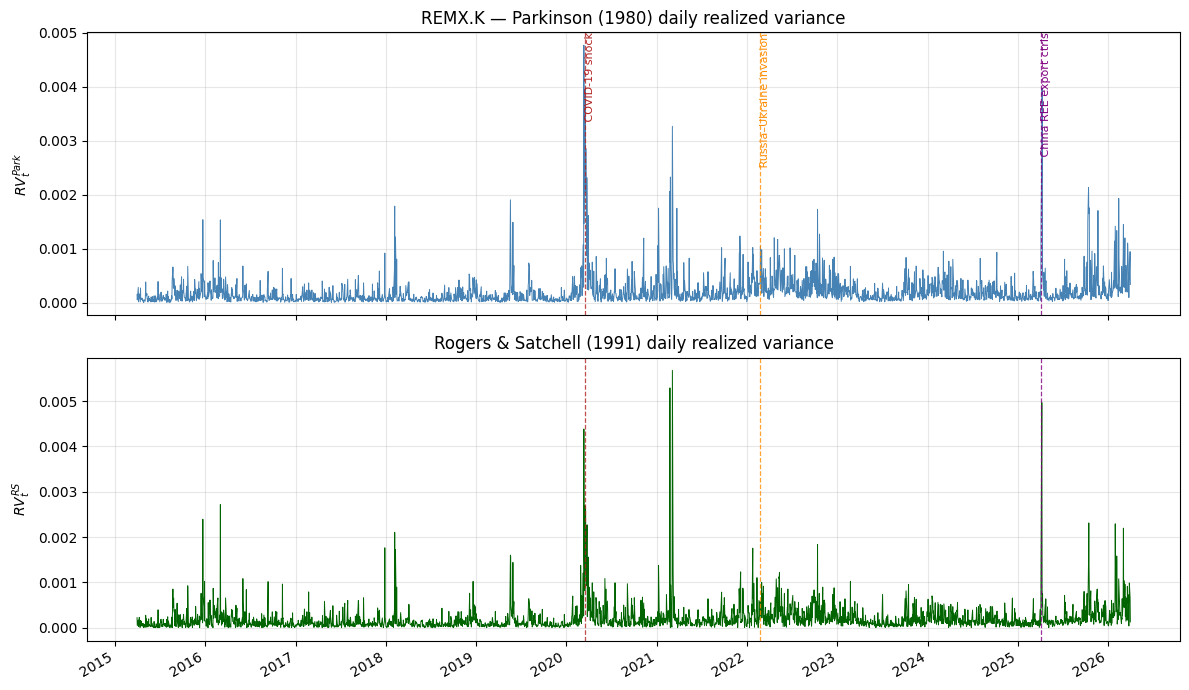


Top-10 RV_park days (should include March 2020 and April 2025):
              Open    High     Low   Close  log_return  RV_park
Date                                                           
2020-03-12 29.7600 30.2900 27.0000 27.8100     -0.1265   0.0048
2025-04-08 35.9400 35.9400 32.3600 32.6500     -0.0411   0.0040
2020-03-17 25.5600 28.3800 25.5600 27.6600      0.1369   0.0040
2025-04-09 33.3500 36.9000 33.3500 36.7300      0.1177   0.0037
2021-03-05 79.5300 79.7600 72.5200 77.0400     -0.0297   0.0033
2020-03-16 26.2500 26.2500 23.9100 24.1200     -0.1742   0.0031
2020-03-20 27.9600 28.2000 25.8000 26.0100     -0.0506   0.0029
2025-04-07 33.5400 36.2000 33.2200 34.0200     -0.0186   0.0027
2021-02-25 89.4000 89.4000 82.5000 82.5000     -0.0958   0.0023
2020-03-24 25.5300 27.6600 25.5300 27.0000      0.1017   0.0023

Top-10 RV_rs days:
              Open    High     Low   Close  log_return  RV_rs
Date                                                         
2021-03-05 79.5300 79.7

In [32]:
# =============================================================================
# Step 1.5 — Diagnostic checks on the RV series
# Descriptive statistics + time-series plot with key REE event markers.
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

rv_cols = ['RV_park', 'RV_rs']

# --- Descriptive statistics (mean, std, skewness, kurtosis + min/max/N) ----
desc = pd.DataFrame({
    'N'        : remx[rv_cols].notna().sum(),
    'Mean'     : remx[rv_cols].mean(),
    'Std'      : remx[rv_cols].std(),
    'Min'      : remx[rv_cols].min(),
    'Max'      : remx[rv_cols].max(),
    'Skewness' : remx[rv_cols].apply(lambda s: stats.skew(s.dropna())),
    'Kurtosis' : remx[rv_cols].apply(lambda s: stats.kurtosis(s.dropna(), fisher=True)),  # excess kurtosis
})
print('Descriptive statistics of the daily realized variance series')
print('(Fisher excess kurtosis: normal = 0)')
print(desc.to_string(float_format=lambda x: f'{x:.6g}'))
print()
print(f'Correlation Parkinson ↔ Rogers-Satchell : '
      f'{remx[rv_cols].corr().iloc[0,1]:.4f}')
print()
print(f'Annualised √(mean RV_park) ≈ {np.sqrt(remx["RV_park"].mean() * 252) * 100:.2f}%')
print(f'Annualised √(mean RV_rs)   ≈ {np.sqrt(remx["RV_rs"].mean()   * 252) * 100:.2f}%')

# --- Plot both RV series with documented REE/market event markers ----------
events = {
    "2020-03-16": ("COVID-19 shock",          'firebrick'),
    "2022-02-24": ("Russia–Ukraine invasion", 'darkorange'),
    "2025-04-04": ("China REE export ctrls",  'purple'),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(remx.index, remx['RV_park'], color='steelblue', linewidth=0.7)
ax1.set_ylabel(r'$RV^{Park}_t$')
ax1.set_title(f'{ETF_LABEL} — Parkinson (1980) daily realized variance')
ax1.grid(alpha=0.3)

ax2.plot(remx.index, remx['RV_rs'], color='darkgreen', linewidth=0.7)
ax2.set_ylabel(r'$RV^{RS}_t$')
ax2.set_title('Rogers & Satchell (1991) daily realized variance')
ax2.grid(alpha=0.3)

for date_str, (label, color) in events.items():
    d = pd.Timestamp(date_str)
    if remx.index.min() <= d <= remx.index.max():
        for ax in (ax1, ax2):
            ax.axvline(d, color=color, linestyle='--', linewidth=0.9, alpha=0.8)
        ax1.text(d, ax1.get_ylim()[1], f' {label}',
                 color=color, fontsize=8, va='top', ha='left', rotation=90)

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Inspect the top-10 realized-variance days for each estimator ---------
print('\nTop-10 RV_park days (should include March 2020 and April 2025):')
print(remx.nlargest(10, 'RV_park')[['Open', 'High', 'Low', 'Close', 'log_return', 'RV_park']].to_string())
print('\nTop-10 RV_rs days:')
print(remx.nlargest(10, 'RV_rs')[['Open', 'High', 'Low', 'Close', 'log_return', 'RV_rs']].to_string())

## Step 6 — Consolidate and Export

The consolidated file is written to `CLEANED DATA/RRE_prices_clean.xlsx` with the date as the first column (not the index) for maximum spreadsheet compatibility.

In [33]:
# Consolidate the cleaned series and export to CLEANED DATA/REMX.K-USD-clean.xlsx
from pathlib import Path

OUT_DIR  = Path("../CLEANED DATA")
OUT_PATH = OUT_DIR / "REMX.K-USD-clean.xlsx"
OUT_DIR.mkdir(exist_ok=True)

# Keep only the columns we'll actually use downstream (Steps 1.2–1.5 and beyond).
clean_cols = ["Open", "High", "Low", "Close", "Volume", "log_return", "RV_park", "RV_rs"]
remx_clean = remx[clean_cols].copy()
remx_clean.index.name = "Date"

with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
    remx_clean.to_excel(writer, sheet_name="REMX_clean", index=True)

print(f"Exported {len(remx_clean):,} rows × {len(clean_cols)} cols → {OUT_PATH}")
print(f"  Date range : {remx_clean.index.min().date()} → {remx_clean.index.max().date()}")
print(f"  Columns    : {clean_cols}")
print()
print("Preview:")
print(remx_clean.head().to_string())

Exported 2,766 rows × 8 cols → ../CLEANED DATA/REMX.K-USD-clean.xlsx
  Date range : 2015-04-01 → 2026-03-31
  Columns    : ['Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'RV_park', 'RV_rs']

Preview:
              Open    High     Low   Close    Volume  log_return  RV_park  RV_rs
Date                                                                            
2015-04-01 75.2700 75.9700 74.4300 75.5700 2380.0000         NaN   0.0002 0.0002
2015-04-02 76.0200 76.9200 76.0200 76.6200 1950.0000      0.0138   0.0000 0.0000
2015-04-06 77.2800 79.4700 77.2800 78.9900 4750.0000      0.0305   0.0003 0.0002
2015-04-07 78.9900 79.5000 78.9900 79.2000 1900.0000      0.0027   0.0000 0.0000
2015-04-08 80.8500 82.4400 80.8500 82.1100 4750.0000      0.0361   0.0001 0.0001


## Step 7 — Load GDELT Sentiment Data

The sentiment data originate from the **GDELT Global Knowledge Graph (GKG)**, a real-time index of every news article monitored by GDELT. For each article the GKG extracts an emotional tone vector using a proprietary dictionary of ≈2,500 positive/negative words. The columns provided are:

| Column | Type | Description |
|---|---|---|
| `date_str` | int (YYYYMMDD) | Publication date of the article |
| `url` | str | Unique article URL |
| `tone` | float | Signed net tone: $\text{pos\_score} - \text{neg\_score}$ |
| `pos_score` | float | Positive emotional intensity (≥0) |
| `neg_score` | float | Negative emotional intensity (≥0) |
| `polarity` | float | Total emotional intensity: $\text{pos\_score} + \text{neg\_score}$ |
| `has_neodymium` … `has_rare_earth` | bool | True if the article mentions the corresponding keyword |

The file is filtered to articles mentioning at least one rare-earth keyword, sourced and pre-filtered by Aleix from the full GDELT GKG feed.

In [34]:
SENT_PATH = '../Sentiment data/SentimentData_Aleix_REMX.csv'

sent_raw = pd.read_csv(SENT_PATH)

# date_str is stored as int64 (YYYYMMDD); parse to datetime
sent_raw['Date'] = pd.to_datetime(sent_raw['date_str'].astype(str), format='%Y%m%d')
sent_raw = sent_raw.drop(columns=['date_str'])

cols = ['Date'] + [c for c in sent_raw.columns if c != 'Date']
sent_raw = sent_raw[cols]

print(f'Raw rows      : {len(sent_raw):,}')
print(f'Date range    : {sent_raw["Date"].min().date()} \u2192 {sent_raw["Date"].max().date()}')
print(f'Unique days   : {sent_raw["Date"].nunique():,}')
print()
# print('Null counts per column:')
# print(sent_raw.isna().sum().to_string())
# print()
# print('Sample (3 rows):')
# print(sent_raw.sample(3, random_state=42)[['Date','url','tone','pos_score','neg_score','polarity','has_rare_earth']].to_string(index=False))

Raw rows      : 314,048
Date range    : 2015-04-01 → 2026-04-01
Unique days   : 4,000



# Filtering articles

In [35]:
# Toggle each flag: True = include in the filter, False = ignore.
# Easy to edit — just flip the booleans of the flags you care about.
FLAG_TOGGLES = {
    'has_neodymium':      True,
    'has_praseodymium':   True,
    'has_dysprosium':     True,
    'has_terbium':        True,
    'has_ndpr':           True,
    'has_ndfeb':          True,
    'has_lanthanum':      True,
    'has_cerium':         True,
    'has_samarium':       True,
    'has_europium':       True,
    'has_gadolinium':     True,
    'has_yttrium':        True,
    'has_rare_earth':     True,
    'has_lynas':          True,
    'has_mp_materials':   True,
    'has_jl_mag':         True,
    'has_arafura':        True,
    'has_china_northern': True,
    'has_remx':           True,
}


def filter_articles(sent_raw, toggles=FLAG_TOGGLES, mode='any', min_hits=1):
    """
    Filter articles in `sent_raw` using the boolean `has_*` columns.

    Parameters
    ----------
    sent_raw : DataFrame with one boolean column per flag.
    toggles  : dict[str, bool] — flag name → True (use it) / False (ignore it).
    mode     : 'any'  → keep article if at least 1 active flag is True
               'all'  → keep article only if ALL active flags are True
               'k'    → keep article if at least `min_hits` active flags are True
    min_hits : int — only used when mode='k'.

    Returns
    -------
    Filtered DataFrame (same schema) + column `n_keyword_hits`.
    """
    keywords = [flag for flag, on in toggles.items() if on]
    if not keywords:
        raise ValueError('No flag set to True in toggles — nothing to filter on.')

    missing = [k for k in keywords if k not in sent_raw.columns]
    if missing:
        raise KeyError(f'Columns not found in sent_raw: {missing}')

    flags  = sent_raw[keywords].astype(bool)
    n_hits = flags.sum(axis=1)

    if mode == 'any':
        mask = n_hits >= 1
    elif mode == 'all':
        mask = n_hits == len(keywords)
    elif mode == 'k':
        mask = n_hits >= min_hits
    else:
        raise ValueError(f"mode must be 'any', 'all' or 'k' (got: {mode!r})")

    out = sent_raw.loc[mask].copy()
    out['n_keyword_hits'] = n_hits.loc[mask].values

    # --- Diagnostics --------------------------------------------------------
    print(f'Filter applied   : mode={mode!r}'
          + (f', min_hits={min_hits}' if mode == 'k' else '')
          + f'   ({len(keywords)} active flags of {len(toggles)})')
    print(f'Active flags     : {keywords}')
    print(f'Articles in      : {len(sent_raw):,}')
    print(f'Articles kept    : {len(out):,}  '
          f'({len(out) / len(sent_raw) * 100:.1f}%)')
    print(f'Articles dropped : {len(sent_raw) - len(out):,}')
    print()
    print('Hits per active flag among kept articles:')
    print(out[keywords].astype(bool).sum().sort_values(ascending=False).to_string())

    return out


# --- Example usage ----------------------------------------------------------
sent_raw = filter_articles(sent_raw, toggles=FLAG_TOGGLES, mode='any')

Filter applied   : mode='any'   (19 active flags of 19)
Active flags     : ['has_neodymium', 'has_praseodymium', 'has_dysprosium', 'has_terbium', 'has_ndpr', 'has_ndfeb', 'has_lanthanum', 'has_cerium', 'has_samarium', 'has_europium', 'has_gadolinium', 'has_yttrium', 'has_rare_earth', 'has_lynas', 'has_mp_materials', 'has_jl_mag', 'has_arafura', 'has_china_northern', 'has_remx']
Articles in      : 314,048
Articles kept    : 314,048  (100.0%)
Articles dropped : 0

Hits per active flag among kept articles:
has_cerium            186346
has_rare_earth         92383
has_lynas              26066
has_samarium            5005
has_neodymium           2960
has_mp_materials        2891
has_praseodymium        2124
has_arafura             1730
has_europium            1153
has_terbium             1143
has_gadolinium          1051
has_yttrium             1030
has_lanthanum            877
has_china_northern       702
has_dysprosium           576
has_ndfeb                505
has_ndpr                 45

## Step 8 — Deduplicate Syndicated Articles

GDELT monitors thousands of news aggregators and wire-service mirrors. A single press release — such as a daily SMM price bulletin — can appear **30+ times within one calendar day** as different aggregator sites republish it verbatim or near-verbatim. Including these copies would artificially inflate `article_count` and bias daily sentiment averages toward the tone of the most-syndicated source.

We apply deduplication in two sequential passes:

1. **URL deduplication** — drops exact URL duplicates (same article fetched more than once by the crawler).
2. **Within-day score deduplication** — within each calendar day, drops rows where the tuple $(\text{tone},\, \text{pos\_score},\, \text{neg\_score},\, \text{polarity})$ is identical. This targets syndicated content that carries different aggregator URLs but identical GKG scores, a strong signal of copy-paste redistribution.

Note that two genuinely different articles could in principle produce the same score vector; this is the accepted precision/recall tradeoff for syndication filtering (see Bollen et al., 2011 for a comparable approach on Twitter sentiment).

In [36]:
n_raw = len(sent_raw)

# Pass 1 — exact URL duplicates
sent_dedup = sent_raw.drop_duplicates(subset='url').copy()
n_after_url = len(sent_dedup)
print(f'Pass 1 — URL dedup    : dropped {n_raw - n_after_url:,} rows  ({n_after_url:,} remain)')

# Pass 2 — within-day identical score tuples
sent_dedup = sent_dedup.drop_duplicates(
    subset=['Date', 'tone', 'pos_score', 'neg_score', 'polarity']
).reset_index(drop=True)
n_after_scores = len(sent_dedup)
print(f'Pass 2 — score dedup  : dropped {n_after_url - n_after_scores:,} rows  ({n_after_scores:,} remain)')
print(f'Total removed         : {n_raw - n_after_scores:,} ({(n_raw - n_after_scores)/n_raw*100:.1f}%)')

Pass 1 — URL dedup    : dropped 323 rows  (313,725 remain)
Pass 2 — score dedup  : dropped 35,840 rows  (277,885 remain)
Total removed         : 36,163 (11.5%)


## Step 9 — Outlier Detection (Polarity)

Within each calendar day, articles with extreme `polarity` values are excluded before aggregation. An article is considered an outlier if its polarity falls outside the **IQR fences** computed from the other articles of the same day:

$$\text{lower} = Q_1 - 1.5 \cdot \text{IQR}, \qquad \text{upper} = Q_3 + 1.5 \cdot \text{IQR}$$

where $\text{IQR} = Q_3 - Q_1$ is the interquartile range of `polarity` within that day's group.

### Rationale

- **Within-day comparison**: an article is only flagged relative to the distribution of articles published on the same day, not against the full dataset. This avoids removing articles that are legitimately high-polarity on volatile news days.
- **IQR method**: robust to the non-normality of polarity scores and does not require a distributional assumption.
- **Minimum group size**: days with fewer than 4 articles are left untouched — IQR cannot be computed reliably from 1–3 points, and with so few articles any filtering would risk removing genuine observations.
- **Column choice**: `polarity = pos_score + neg_score` captures total emotional intensity regardless of sign, making it the most sensitive indicator of an anomalous article.

In [37]:
# drop outliers in polarity using a modified IQR method
#also considers the gap to the nearest in-fence point
def remove_polarity_outliers(
    df: pd.DataFrame,
    date_col: str = 'Date',
    multiplier: float = 1.5, #(a): IQR multiplier for defining the outlier fence   <-- NOTE: TUNE
    min_gap: float = 1.5,   #(b): minimum gap to nearest in-fence point for an outlier to be dropped
    min_group_size: int = 4,
) -> pd.DataFrame:
    """
    Drop articles whose polarity is BOTH (a) outside the IQR fence and
    (b) separated from the nearest in-fence point by at least `min_gap`.
    """
    def _filter(group):
        if len(group) < min_group_size:
            return group
        q1 = group['polarity'].quantile(0.25)
        q3 = group['polarity'].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
        cand_mask = (group['polarity'] < lower) | (group['polarity'] > upper)
        if not cand_mask.any():
            return group
        interior = group.loc[~cand_mask, 'polarity'].values
        if len(interior) == 0:
            return group
        keep = ~cand_mask.copy()
        for idx in group.index[cand_mask]:
            v = group.loc[idx, 'polarity']
            if np.min(np.abs(interior - v)) < min_gap:
                keep.loc[idx] = True
        return group[keep]

    return (
        df.groupby(date_col, group_keys=False)
          .apply(_filter)
          .reset_index(drop=True)
    )


df_without_outlier = remove_polarity_outliers(sent_dedup, date_col='Date')

n_before = len(sent_dedup)
n_after  = len(df_without_outlier)
n_removed = n_before - n_after
print(f'Articles before : {n_before:,}')
print(f'Articles after  : {n_after:,}')
print(f'Removed         : {n_removed:,}  ({n_removed/n_before*100:.2f}%)')

Articles before : 277,885
Articles after  : 273,816
Removed         : 4,069  (1.46%)


/var/folders/3r/98sm1vp9115dskjg4j7xdnnm0000gn/T/ipykernel_30259/1957896704.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(date_col, group_keys=False)


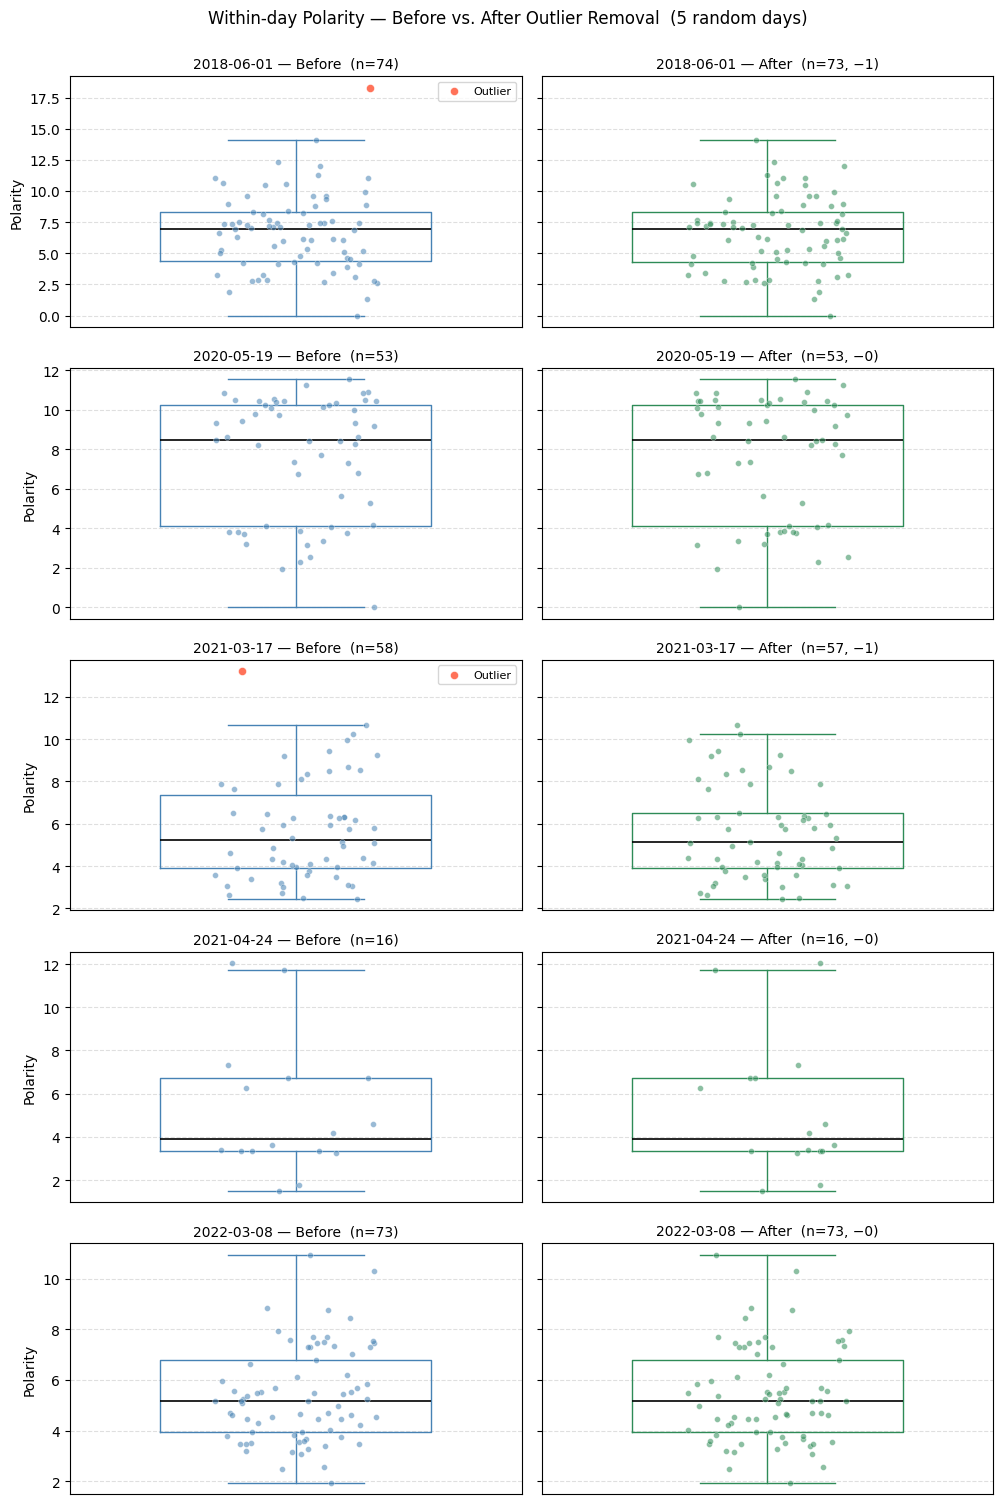

In [38]:
# plot comparison of polarity distributions before vs. after outlier removal
# for a random sample of days

N_DAYS = 5
rng = np.random.default_rng()                       # no seed → new sample each run
jitter_rng = np.random.default_rng(0)

all_days = np.array(sorted(sent_dedup['Date'].unique()))
days = sorted(rng.choice(all_days, size=N_DAYS, replace=False))

fig, axes = plt.subplots(N_DAYS, 2, figsize=(10, 3 * N_DAYS), sharey='row')

for row, d in enumerate(days):
    before_day = sent_dedup[sent_dedup['Date'] == d]
    after_urls = set(df_without_outlier.loc[df_without_outlier['Date'] == d, 'url'])
    is_outlier = ~before_day['url'].isin(after_urls)

    y_before   = before_day['polarity'].values
    y_outliers = before_day.loc[ is_outlier, 'polarity'].values
    y_inliers  = before_day.loc[~is_outlier, 'polarity'].values
    y_after    = df_without_outlier.loc[df_without_outlier['Date'] == d, 'polarity'].values

    # ── Left subplot: BEFORE (outliers in red) ─────────────────────────────
    ax_l = axes[row, 0]
    ax_l.boxplot(
        y_before, positions=[1], widths=0.6, showfliers=False,
        medianprops=dict(color='black', linewidth=1.2),
        boxprops=dict(color='steelblue'),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
    )
    if len(y_inliers) > 0:
        x = 1 + jitter_rng.uniform(-0.18, 0.18, size=len(y_inliers))
        ax_l.scatter(x, y_inliers, s=18, color='steelblue', alpha=0.55,
                     edgecolor='white', linewidth=0.4, zorder=3)
    if len(y_outliers) > 0:
        x = 1 + jitter_rng.uniform(-0.18, 0.18, size=len(y_outliers))
        ax_l.scatter(x, y_outliers, s=34, color='tomato', alpha=0.9,
                     edgecolor='white', linewidth=0.4, zorder=4, label='Outlier')
        ax_l.legend(loc='upper right', fontsize=8)

    ax_l.set_title(f'{pd.Timestamp(d).strftime("%Y-%m-%d")} — Before  (n={len(y_before)})',
                   fontsize=10)
    ax_l.set_xticks([])
    ax_l.set_ylabel('Polarity')
    ax_l.grid(True, axis='y', linestyle='--', alpha=0.4)

    # ── Right subplot: AFTER (no red points) ───────────────────────────────
    ax_r = axes[row, 1]
    ax_r.boxplot(
        y_after, positions=[1], widths=0.6, showfliers=False,
        medianprops=dict(color='black', linewidth=1.2),
        boxprops=dict(color='seagreen'),
        whiskerprops=dict(color='seagreen'),
        capprops=dict(color='seagreen'),
    )
    if len(y_after) > 0:
        x = 1 + jitter_rng.uniform(-0.18, 0.18, size=len(y_after))
        ax_r.scatter(x, y_after, s=18, color='seagreen', alpha=0.55,
                     edgecolor='white', linewidth=0.4, zorder=3)

    n_removed = len(y_before) - len(y_after)
    ax_r.set_title(f'{pd.Timestamp(d).strftime("%Y-%m-%d")} — After  '
                   f'(n={len(y_after)}, −{n_removed})', fontsize=10)
    ax_r.set_xticks([])
    ax_r.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Within-day Polarity — Before vs. After Outlier Removal  (5 random days)',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

(EXTRACT A LIST OF 50 URLS OF WHAT WE DETECT AS OUTLIERS, TO MAKE THE CHECK MANUALLY)

## Step 10 — Aggregate to Daily Sentiment Series

We collapse the deduplicated article-level data to **one row per calendar day**.

| Variable | Formula | Model use |
|---|---|---|
| `tone_mean` | $\bar{T}_t = \frac{1}{N_t}\sum_{i} \text{tone}_i$ | Signed sentiment direction (EGARCH-X) |
| `polarity_mean` | $\bar{P}_t = \frac{1}{N_t}\sum_{i} \text{polarity}_i$ | Total emotional intensity (GJR-X) |
| `pos_tone_mean` | $\bar{P^{+}}_t = \frac{1}{N_t}\sum_{i} \text{pos\_score}_i$ | Good-news intensity (EGARCH-X) |
| `neg_tone_mean` | $\bar{N}_t = \frac{1}{N_t}\sum_{i} \text{neg\_score}_i$ | Bad-news intensity (GJR-X) |
| `article_count` | $N_t$ | Raw article volume |
| `log_article_count` | $\ln(1 + N_t)$ | Log-transformed volume (EGARCH-X) |

Per-metal article counts (`n_nd`, `n_pr`, `n_dy`, `n_tb`, `n_ndpr`, `n_ndfeb`, `n_rare_earth`) are preserved so that metal-specific sentiment indices can be constructed in robustness checks without re-running deduplication.

**No standardisation and no lagging** are performed here. Both operations use in-sample-only statistics and belong in the modelling code to prevent look-ahead bias.

In [39]:
def aggregate_sentiment(df: pd.DataFrame, date_col: str = 'Date') -> pd.DataFrame:
    """Aggregate article-level sentiment to daily series."""
    grp = df.groupby(date_col)
    daily = grp.agg(
        tone_mean      = ('tone',            'mean'),
        polarity_mean  = ('polarity',        'mean'),
        pos_tone_mean  = ('pos_score',       'mean'),
        neg_tone_mean  = ('neg_score',       'mean'),
        article_count  = ('tone',            'count'),
    ).reset_index().rename(columns={date_col: 'Date'})
    daily['log_article_count'] = np.log1p(daily['article_count'])
    daily = daily.set_index('Date').sort_index()
    return daily


sent_daily = aggregate_sentiment(sent_dedup)

print(f'Daily rows    : {len(sent_daily):,}')
print(f'Date range    : {sent_daily.index.min().date()} \u2192 {sent_daily.index.max().date()}')
print(f'Articles/day  : mean={sent_daily["article_count"].mean():.1f}, max={sent_daily["article_count"].max()}')
print()
print('Null counts:')
print(sent_daily.isna().sum().to_string())

Daily rows    : 4,000
Date range    : 2015-04-01 → 2026-04-01
Articles/day  : mean=69.5, max=1090

Null counts:
tone_mean            0
polarity_mean        0
pos_tone_mean        0
neg_tone_mean        0
article_count        0
log_article_count    0


## Step 11 — Roll Weekend and Holiday News into the Next Trading Day

Rare-earth markets (like most commodity markets) operate on weekdays only. News published on a **Saturday or Sunday** is information that market participants absorb over the weekend and act upon at **Monday's open**. Discarding weekend articles would lose 13–15% of the dataset; treating them as Monday observations is the standard approach in the news-sentiment literature (see Tetlock, 2007; Garcia, 2013).

### Implementation

We work from the **deduplicated article-level** DataFrame (not from `sent_daily`), for an important reason: if we had already aggregated to daily means and then simply shifted the Saturday/Sunday rows forward, we would be computing a straight average of shifted-day means. Working at the article level and then re-aggregating after the date shift gives correctly **article-count-weighted means** — the mean tone of all articles (regardless of their raw publication date) that are informationally relevant to a given trading day.

For each article, we compute a `Date_aligned` column:
$$\text{Date\_aligned} = \begin{cases} \text{Date} & \text{if Date is a business day} \\ \text{next business day after Date} & \text{otherwise} \end{cases}$$

We then re-run the Step 13 aggregation on `Date_aligned` to produce the final `sent_daily` index.

In [40]:
import numpy as np

# --- Real trading calendar from REMX data ---
# `remx` now uses Date as the DatetimeIndex (no 'Date' column), so pull from the index.
trading_days = pd.DatetimeIndex(sorted(remx.index.unique()))

# --- Aligning articles to trading days ---
positions = trading_days.searchsorted(sent_dedup['Date'].values, side='left')
out_of_bounds = positions >= len(trading_days)
positions_clipped = np.clip(positions, 0, len(trading_days) - 1)

sent_dedup = sent_dedup.copy()
sent_dedup['Date_aligned'] = trading_days[positions_clipped]
sent_dedup.loc[out_of_bounds, 'Date_aligned'] = pd.NaT

# --- Discard articles published after the last trading day → they are dropped ---
n_dropped = sent_dedup['Date_aligned'].isna().sum()
if n_dropped > 0:
    print(f'Articles after last trading day (dropped): {n_dropped:,}')
sent_dedup = sent_dedup.dropna(subset=['Date_aligned']).reset_index(drop=True)

# --- Information Report ---
shifted = sent_dedup[sent_dedup['Date_aligned'] != sent_dedup['Date']]
print(f'Articles shifted to next trading day : {len(shifted):,}')
print('Breakdown by original day-of-week:')
print(shifted['Date'].dt.day_name().value_counts().to_string())
print()

# Holiday-specific check: articles whose original date is a weekday but got shifted
holiday_shifts = shifted[shifted['Date'].dt.dayofweek < 5]
print(f'Articles shifted from a weekday (i.e. holiday): {len(holiday_shifts):,}')
print()

# --- Re-aggregate on aligned date ---
sent_daily_rolled = aggregate_sentiment(sent_dedup, date_col='Date_aligned')

print(f'Daily rows after realignment : {len(sent_daily_rolled):,}')
print(f'Date range                   : '
      f'{sent_daily_rolled.index.min().date()} → {sent_daily_rolled.index.max().date()}')
print()

# Sanity check: 2015-04-03 (Good Friday) should NOT be in the index;
# its sentiment should be folded into 2015-04-06
check = sent_daily_rolled.index.normalize()
print(f'2015-04-03 in index? {pd.Timestamp("2015-04-03") in check}  (expected: False)')
print(f'2015-04-06 in index? {pd.Timestamp("2015-04-06") in check}  (expected: True)')


Articles after last trading day (dropped): 124
Articles shifted to next trading day : 58,088
Breakdown by original day-of-week:
Date
Sunday       26171
Saturday     24715
Monday        4343
Thursday      1263
Friday        1064
Wednesday      355
Tuesday        177

Articles shifted from a weekday (i.e. holiday): 7,202

Daily rows after realignment : 2,755
Date range                   : 2015-04-01 → 2026-03-31

2015-04-03 in index? False  (expected: False)
2015-04-06 in index? True  (expected: True)


In [41]:
sent_daily[:10]

,tone_mean,polarity_mean,pos_tone_mean,neg_tone_mean,article_count,log_article_count
Date,,,,,,
2015-04-01,-0.3725,6.1317,2.8796,3.2521,77,4.3567
2015-04-02,-0.3851,5.5743,2.5946,2.9797,50,3.9318
2015-04-03,-1.0914,4.8494,1.8790,2.9704,74,4.3175
2015-04-04,-1.1632,4.1569,1.4969,2.6601,47,3.8712
2015-04-05,-0.5399,6.2822,2.8712,3.4110,17,2.8904
2015-04-06,-0.5694,5.1789,2.3048,2.8742,54,4.0073
2015-04-07,0.2419,4.4167,2.3293,2.0874,71,4.2767
2015-04-08,0.6474,4.9362,2.7918,2.1444,48,3.8918
2015-04-09,0.0754,5.2733,2.6743,2.5990,73,4.3041


In [42]:

sent_daily_rolled[:10]

,tone_mean,polarity_mean,pos_tone_mean,neg_tone_mean,article_count,log_article_count
Date,,,,,,
2015-04-01,-0.3725,6.1317,2.8796,3.2521,77,4.3567
2015-04-02,-0.3851,5.5743,2.5946,2.9797,50,3.9318
2015-04-06,-0.9133,4.8994,1.9930,2.9064,192,5.2627
2015-04-07,0.2419,4.4167,2.3293,2.0874,71,4.2767
2015-04-08,0.6474,4.9362,2.7918,2.1444,48,3.8918
2015-04-09,0.0754,5.2733,2.6743,2.5990,73,4.3041
2015-04-10,-0.0378,5.7897,2.8760,2.9137,54,4.0073
2015-04-13,-0.0174,5.6074,2.7950,2.8124,91,4.5218
2015-04-14,-0.5709,4.9193,2.1742,2.7451,52,3.9703


We can visually check that the tone and polarity averages on Mondays correspond to the weighted averages of Saturday, Sunday and Monday (we have rolled the weekend sentiment to Monday, as the hypothesis is that prices on Mondays also reflect weekend's sentiment).

## Step 12 — Merge Sentiment with Price Data

In [43]:
OUTPUT_DIR = '../CLEANED DATA'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 1. Load the cleaned REMX price file ---
price_path = os.path.join(OUTPUT_DIR, 'REMX.K-USD-clean.xlsx')
remx_clean = pd.read_excel(price_path)
remx_clean['Date'] = pd.to_datetime(remx_clean['Date'])

# --- 2. Make sure sent_daily_rolled has Date as a column (not just index) ---
sent_df = sent_daily_rolled.copy()
if 'Date' not in sent_df.columns:
    sent_df = sent_df.reset_index().rename(columns={'index': 'Date'})
sent_df['Date'] = pd.to_datetime(sent_df['Date'])

# --- 3. Merge on Date (LEFT join: keep every REMX trading day, even those
#        with zero articles, so the panel preserves a contiguous trading
#        calendar for downstream returns and volatility estimators) -------
combined = remx_clean.merge(sent_df, on='Date', how='left').sort_values('Date').reset_index(drop=True)

# Days with zero articles get NaN from the merge. Per methodology, fill the
# sentiment fields with 0: no articles -> no tone signal that day. log_article_count
# is np.log1p(article_count), so it is also 0 on those days.
sentiment_fill_cols = [
    'tone_mean', 'polarity_mean', 'pos_tone_mean', 'neg_tone_mean',
    'article_count', 'log_article_count',
]
for c in sentiment_fill_cols:
    if c in combined.columns:
        combined[c] = combined[c].fillna(0)

# Restore integer dtype for article_count (fillna promotes it to float).
if 'article_count' in combined.columns:
    combined['article_count'] = combined['article_count'].astype(int)

# --- 4. Article-volume growth indicators ------------------------------------
# article_count on a Monday already contains the SUM of Sat + Sun + Mon
# articles (they were rolled in Step 11). To stay comparable with G&P, we
# average the rolled count over the calendar gap before comparing it to the
# previous trading day's per-day mean:
#
#     art_growth_t = ( mean_per_day_t - mean_per_day_{t_prev} ) / mean_per_day_{t_prev}
#
# Since article_count[t] = SUM over those k calendar days, the per-day
# mean is simply article_count[t] / k, with k = (Date_t - Date_{t_prev}).days.
#   * Mon -> Tue       : k = 1 -> collapses to plain G&P pct change
#   * Fri -> Mon       : k = 3 -> avg(Sat, Sun, Mon) compared to Fri's per-day mean
#   * Thu -> Mon (Easter, Good Friday holiday) : k = 4 -> avg(Fri, Sat, Sun, Mon)
# Using mean_per_day on BOTH sides keeps the comparison consistent when the
# previous trading day itself follows a holiday (otherwise we would compare a
# 1-day mean against a multi-day sum).
# Edge cases:
#   * Day 0 (no previous trading day)         -> growth set to 0
#   * Previous trading day with 0 articles    -> division by zero -> 0
gap              = (combined['Date'] - combined['Date'].shift(1)).dt.days
avg_per_day      = combined['article_count'] / gap
prev_avg_per_day = avg_per_day.shift(1)
art_growth       = (avg_per_day - prev_avg_per_day) / prev_avg_per_day
combined['art_growth'] = art_growth.replace([np.inf, -np.inf], np.nan).fillna(0)

# Log-difference of (1 + article_count): a symmetric, bounded-variance variant
# that is well-defined even when N_{t-1} = 0 and is roughly equivalent to
# art_growth for large counts but tames the spikes for small counts.
#     log_art_growth_t = log(1 + N_t) - log(1 + N_{t-1})
combined['log_art_growth'] = (
    np.log1p(combined['article_count'])
    - np.log1p(combined['article_count'].shift(1))
).fillna(0)

n_zero_article_days = int((combined['article_count'] == 0).sum())
print(f'Trading days with zero articles (filled with 0s) : {n_zero_article_days}')
print(f"art_growth summary      "
      f"mean={combined['art_growth'].mean():.4f}  "
      f"std={combined['art_growth'].std():.4f}  "
      f"min={combined['art_growth'].min():.4f}  "
      f"max={combined['art_growth'].max():.4f}")
print(f"log_art_growth summary  "
      f"mean={combined['log_art_growth'].mean():.4f}  "
      f"std={combined['log_art_growth'].std():.4f}  "
      f"min={combined['log_art_growth'].min():.4f}  "
      f"max={combined['log_art_growth'].max():.4f}")

# --- 5. Save combined file ---
out_path = os.path.join(OUTPUT_DIR, 'REMX_prices_sentiment_combined.xlsx')
combined.to_excel(out_path, index=False)
print(f'Saved : {out_path}')
print(f'Shape : {combined.shape}  ({combined.shape[0]:,} rows x {combined.shape[1]} columns)')


Trading days with zero articles (filled with 0s) : 11
art_growth summary      mean=0.1458  std=1.3173  min=-1.0000  max=61.0000
log_art_growth summary  mean=0.0002  std=0.6904  min=-4.2047  max=5.1240
Saved : ../CLEANED DATA/REMX_prices_sentiment_combined.xlsx
Shape : (2766, 17)  (2,766 rows x 17 columns)


## Step 13 — Visual Sanity Check on Sentiment Series

Before committing the merged panel to disk, we visually inspect the three core sentiment series for obvious data artefacts: level shifts, extended periods of zero coverage, or extreme spikes that might indicate a crawler outage or classification error.

A **30-day rolling mean** is overlaid on the tone and polarity series to reveal low-frequency sentiment trends, which are of primary interest for the volatility models.

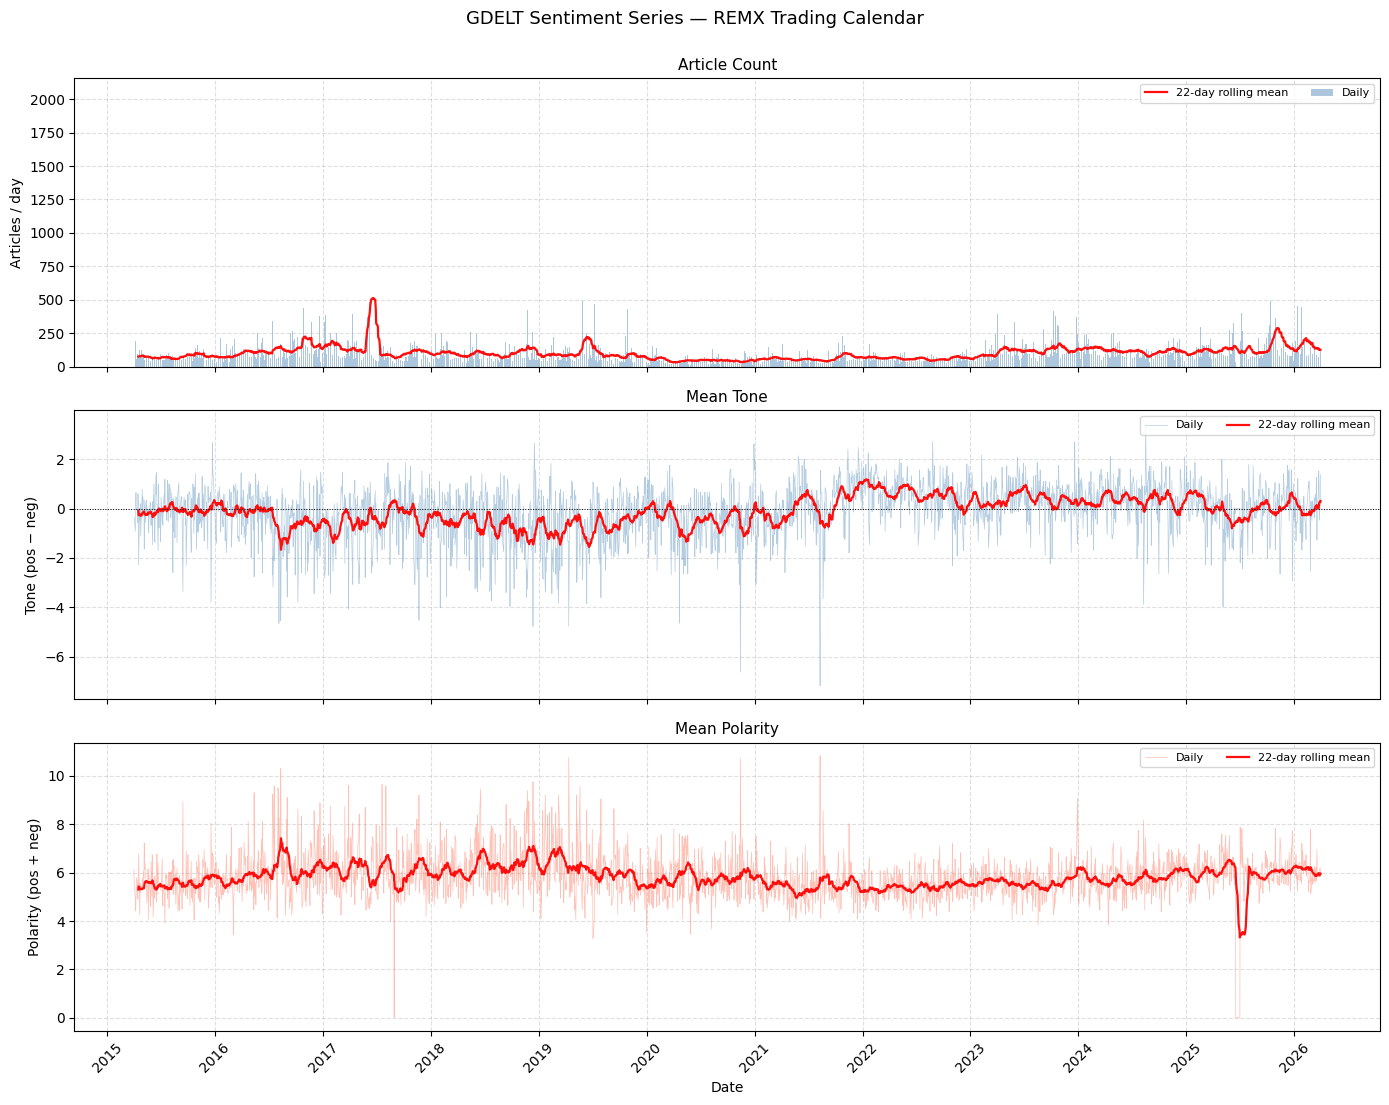

In [44]:
import matplotlib.dates as mdates

combined = pd.read_excel('../CLEANED DATA/REMX_prices_sentiment_combined.xlsx')
combined['Date'] = pd.to_datetime(combined['Date'])
combined = combined.sort_values('Date').set_index('Date')

WINDOWS =   [
            #5,
            #10,
            22]

ROLL_COLORS = {22: "#ff0e0e"}
#{5: '#9467bd',
#10: '#2ca02c',
               

series_specs = [
    ('article_count', 'Article Count',     'Articles / day',           'steelblue', 'bar'),
    ('tone_mean',     'Mean Tone',         'Tone (pos − neg)',         'steelblue', 'line'),
    ('polarity_mean', 'Mean Polarity',     'Polarity (pos + neg)',     'tomato',    'line'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

for ax, (col, title, ylabel, base_color, kind) in zip(axes, series_specs):
    s = combined[col]

    if kind == 'bar':
        ax.bar(s.index, s.values, width=1.0, color=base_color, alpha=0.45, label='Daily')
    else:
        ax.plot(s.index, s.values, linewidth=0.5, color=base_color, alpha=0.4, label='Daily')

    for w in WINDOWS:
        roll = s.rolling(window=w, min_periods=max(2, w // 2)).mean()
        ax.plot(roll.index, roll.values, linewidth=1.6,
                color=ROLL_COLORS[w], label=f'{w}-day rolling mean')

    if col == 'tone_mean':
        ax.axhline(0, color='black', linewidth=0.7, linestyle=':')

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8, loc='upper right', ncol=2)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', rotation=45)
axes[-1].set_xlabel('Date')

plt.suptitle('GDELT Sentiment Series — REMX Trading Calendar', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()


## Step 18 — Final Summary

In [45]:
combined = pd.read_excel('../CLEANED DATA/REMX_prices_sentiment_combined.xlsx')
combined['Date'] = pd.to_datetime(combined['Date'])
combined = combined.sort_values('Date').reset_index(drop=True)

# ── Section 1 — Coverage ─────────────────────────────────────────────────────
n_rows      = len(combined)
date_min    = combined['Date'].min().date()
date_max    = combined['Date'].max().date()
n_with_news = int((combined['article_count'] > 0).sum())
n_no_news   = int((combined['article_count'] == 0).sum())

# ── Section 2 — Price & returns stats ────────────────────────────────────────
price_stats = combined['Close'].describe()[['mean', 'std', 'min', 'max']]
ret = combined['log_return'].dropna()
ret_stats = {
    'N':        len(ret),
    'Mean':     ret.mean(),
    'Std':      ret.std(),
    'Skewness': sp_stats.skew(ret),
    'Kurtosis': sp_stats.kurtosis(ret),   # excess kurtosis
    'Min':      ret.min(),
    'Max':      ret.max(),
}

# ── Section 3 — Sentiment aggregates ────────────────────────────────────────
sent_cols = ['tone_mean', 'polarity_mean', 'pos_tone_mean', 'neg_tone_mean']
sent_stats = combined[sent_cols].agg(['mean', 'std', 'min', 'max']).T

article_stats = {
    'Total articles (sum)':  int(combined['article_count'].sum()),
    'Articles/day  mean':    combined['article_count'].mean(),
    'Articles/day  median':  combined['article_count'].median(),
    'Articles/day  max':     int(combined['article_count'].max()),
}

# ── Section 4 — Per-metal article counts ────────────────────────────────────
n_cols = [c for c in combined.columns if c.startswith('n_')]
per_metal = {c: int(combined[c].sum()) for c in n_cols}

# ── Section 5 — NaN audit ───────────────────────────────────────────────────
nan_counts = combined.isna().sum()
nan_counts = nan_counts[nan_counts > 0]

# ── Print report ────────────────────────────────────────────────────────────
def hr(char='─', n=70): print(char * n)

print('FINAL COMBINED DATASET — SUMMARY')
hr('═')
print(f'File          : CLEANED DATA/REMX_prices_sentiment_combined.xlsx')
print(f'Shape         : {combined.shape[0]:,} rows × {combined.shape[1]} columns')
print(f'Timeframe     : {date_min} → {date_max}')
print(f'Trading days with ≥1 article : {n_with_news:,}')
print(f'Trading days with 0 articles : {n_no_news:,}')
print()

print('Columns:')
for c in combined.columns:
    print(f'  • {c}')
print()

hr()
print('PRICE & LOG RETURNS')
hr()
print(f'REMX price   : mean={price_stats["mean"]:.2f}  std={price_stats["std"]:.2f}  '
      f'min={price_stats["min"]:.2f}  max={price_stats["max"]:.2f}')
print('Log returns  :')
for k, v in ret_stats.items():
    print(f'   {k:<10}: {v:,.4f}' if isinstance(v, float) else f'   {k:<10}: {v:,}')
print()

hr()
print('SENTIMENT AGGREGATES')
hr()
print(sent_stats.to_string(float_format=lambda x: f'{x:,.4f}'))
print()
print('Article counts:')
for k, v in article_stats.items():
    print(f'   {k:<24}: {v:,.2f}' if isinstance(v, float) else f'   {k:<24}: {v:,}')
print()

hr()
print('PER-METAL ARTICLE COUNTS (sum across all days)')
hr()
for c, v in per_metal.items():
    print(f'  {c:<16}: {v:,}')
print()

hr()
print('MISSING-VALUE AUDIT')
hr()
if nan_counts.empty:
    print('  No missing values.')
else:
    for col, n in nan_counts.items():
        print(f'  {col:<20}: {n:,} NaN  ({n/n_rows*100:.2f}%)')
print()

hr('═')
print('END OF SUMMARY')


FINAL COMBINED DATASET — SUMMARY
══════════════════════════════════════════════════════════════════════
File          : CLEANED DATA/REMX_prices_sentiment_combined.xlsx
Shape         : 2,766 rows × 17 columns
Timeframe     : 2015-04-01 → 2026-03-31
Trading days with ≥1 article : 2,755
Trading days with 0 articles : 11

Columns:
  • Date
  • Open
  • High
  • Low
  • Close
  • Volume
  • log_return
  • RV_park
  • RV_rs
  • tone_mean
  • polarity_mean
  • pos_tone_mean
  • neg_tone_mean
  • article_count
  • log_article_count
  • art_growth
  • log_art_growth

──────────────────────────────────────────────────────────────────────
PRICE & LOG RETURNS
──────────────────────────────────────────────────────────────────────
REMX price   : mean=63.43  std=22.53  min=24.12  max=127.41
Log returns  :
   N         : 2,765
   Mean      : 0.0001
   Std       : 0.0229
   Skewness  : -0.1418
   Kurtosis  : 3.6993
   Min       : -0.1742
   Max       : 0.1369

─────────────────────────────────────────

## Step 14 — Alternative dataset à la Guidolin & Pedio (no weekend rolling)

Guidolin & Pedio (2019) handle the calendar mismatch between 24/7 news data and the trading-day return series differently from the previous section:

- **Weekend / holiday articles are dropped, not rolled.** Only articles published on a trading day are kept; news that falls on a non-trading day is discarded entirely. (See Section 2 of the paper, pp. 7–9.)
- **Article growth, not log-level.** Attention enters their GARCH-X through the *growth rate* of the daily article count (their Eq. 1, p. 7):

    $$\text{art\_growth}_t \;=\; \frac{\omega_t - \omega_{t-1}}{\omega_{t-1}}$$

    where $\omega_t$ is the total number of articles on day $t$. This is a simple percent change, not $\log(1 + N_t)$.

We keep the original combined dataset untouched and build a second file, `CLEANED DATA/REMX_prices_sentiment_combined_GP.xlsx`, following these two conventions. Trading days with zero articles still get filled with zeros (so the panel remains a contiguous trading calendar for downstream volatility models); `art_growth` on days where the previous count was zero is set to 0 (undefined → no signal).

In [46]:
# === Guidolin & Pedio (2019) alternative: discard weekend/holiday articles,
#     use article growth (Eq. 1) in addition to log_article_count ===========

trading_set = set(pd.to_datetime(remx_clean['Date']))

# 1. Keep only articles whose publication date is itself a trading day -------
sent_tradingday = sent_dedup[sent_dedup['Date'].isin(trading_set)].copy()
n_kept    = len(sent_tradingday)
n_dropped = len(sent_dedup) - n_kept
print(f'Articles kept (published on a trading day)      : {n_kept:,}')
print(f'Articles dropped (weekend/holiday publication)  : {n_dropped:,}')

# 2. Aggregate to daily on the trading-day calendar --------------------------
sent_daily_gp = aggregate_sentiment(sent_tradingday)

# 3. Merge with prices (left join; zero-article trading days filled with 0) --
sent_df_gp = sent_daily_gp.reset_index()
sent_df_gp['Date'] = pd.to_datetime(sent_df_gp['Date'])

combined_gp = (
    remx_clean.merge(sent_df_gp, on='Date', how='left')
              .sort_values('Date')
              .reset_index(drop=True)
)

fill_zero_cols = [
    'tone_mean', 'polarity_mean', 'pos_tone_mean', 'neg_tone_mean',
    'article_count', 'log_article_count',
]
for c in fill_zero_cols:
    if c in combined_gp.columns:
        combined_gp[c] = combined_gp[c].fillna(0)
combined_gp['article_count'] = combined_gp['article_count'].astype(int)

# 4. Article growth a la G&P (Eq. 1): (N_t - N_{t-1}) / N_{t-1} ---------------
#    - day 0 (no previous count)            -> growth undefined -> 0
#    - day with N_{t-1} == 0                -> growth undefined -> 0
#    - day with N_t == 0, N_{t-1} > 0       -> growth = -1 (valid: drop to zero)
prev   = combined_gp['article_count'].shift(1)
growth = (combined_gp['article_count'] - prev) / prev
combined_gp['art_growth'] = growth.replace([np.inf, -np.inf], np.nan).fillna(0)

# Symmetric log-growth: log(1 + N_t) - log(1 + N_{t-1}). Well-defined even when
# N_{t-1} = 0; near-equivalent to art_growth for large counts; less spikey for
# small counts.
combined_gp['log_art_growth'] = (
    np.log1p(combined_gp['article_count'])
    - np.log1p(combined_gp['article_count'].shift(1))
).fillna(0)

# Note: log_article_count is kept alongside art_growth so downstream models
# can choose whichever specification they prefer.

# 5. Save --------------------------------------------------------------------
out_path_gp = os.path.join(OUTPUT_DIR,
                           'REMX_prices_sentiment_combined_GP.xlsx')
combined_gp.to_excel(out_path_gp, index=False)

print()
print(f'Saved : {out_path_gp}')
print(f'Shape : {combined_gp.shape}  '
      f'({combined_gp.shape[0]:,} rows x {combined_gp.shape[1]} columns)')

print()
print('art_growth / log_art_growth summary (G&P, Eq. 1 variants):')
print(combined_gp[['art_growth', 'log_art_growth']]
      .describe().loc[['mean','std','min','max']]
      .to_string(float_format=lambda x: f'{x: .4f}'))

print()
print('Head:')
print(combined_gp.head().to_string(index=False))


Articles kept (published on a trading day)      : 219,673
Articles dropped (weekend/holiday publication)  : 58,088

Saved : ../CLEANED DATA/REMX_prices_sentiment_combined_GP.xlsx
Shape : (2766, 17)  (2,766 rows x 17 columns)

art_growth / log_art_growth summary (G&P, Eq. 1 variants):
      art_growth  log_art_growth
mean      0.1313          0.0002
std       1.2952          0.4775
min      -1.0000         -4.8675
max      61.0000          5.1240

Head:
      Date    Open    High     Low   Close    Volume  log_return  RV_park  RV_rs  tone_mean  polarity_mean  pos_tone_mean  neg_tone_mean  article_count  log_article_count  art_growth  log_art_growth
2015-04-01 75.2700 75.9700 74.4300 75.5700 2380.0000         NaN   0.0002 0.0002    -0.3725         6.1317         2.8796         3.2521             77             4.3567      0.0000          0.0000
2015-04-02 76.0200 76.9200 76.0200 76.6200 1950.0000      0.0138   0.0000 0.0000    -0.3851         5.5743         2.5946         2.9797         